<a href="https://colab.research.google.com/github/omkulawade03/Dataset/blob/main/Optional%20Task20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [82]:
from google.colab import files

uploaded = files.upload()

Saving amazon.csv to amazon (5).csv


In [83]:
filepath = "/content/amazon.csv"
df = pd.read_csv("amazon.csv")

In [86]:
# --------------------------------------------
# Load Dataset
# --------------------------------------------
df = pd.read_csv("amazon.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)


First 5 Rows
   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349         

In [87]:
# --------------------------------------------
# Data Cleaning
# --------------------------------------------

# Keep required columns
data = df[['discounted_price','actual_price',
           'discount_percentage','rating']]

# Remove symbols
data['discounted_price'] = data['discounted_price'].astype(str).str.replace('₹','',regex=False).str.replace(',','',regex=False)

data['actual_price'] = data['actual_price'].astype(str).str.replace('₹','',regex=False).str.replace(',','',regex=False)

data['discount_percentage'] = data['discount_percentage'].astype(str).str.replace('%','',regex=False)

# Convert into numeric
data = data.apply(pd.to_numeric, errors='coerce')

# Remove missing values
data.dropna(inplace=True)

print("\nCleaned Data")
print(data.head())


Cleaned Data
   discounted_price  actual_price  discount_percentage  rating
0             399.0        1099.0                   64     4.2
1             199.0         349.0                   43     4.0
2             199.0        1899.0                   90     3.9
3             329.0         699.0                   53     4.2
4             154.0         399.0                   61     4.2


/tmp/ipykernel_1081/3749721442.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['discounted_price'] = data['discounted_price'].astype(str).str.replace('₹','',regex=False).str.replace(',','',regex=False)
/tmp/ipykernel_1081/3749721442.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['actual_price'] = data['actual_price'].astype(str).str.replace('₹','',regex=False).str.replace(',','',regex=False)
/tmp/ipykernel_1081/3749721442.py:14: SettingWithCopyWarning: 
A value is trying to be set on a 

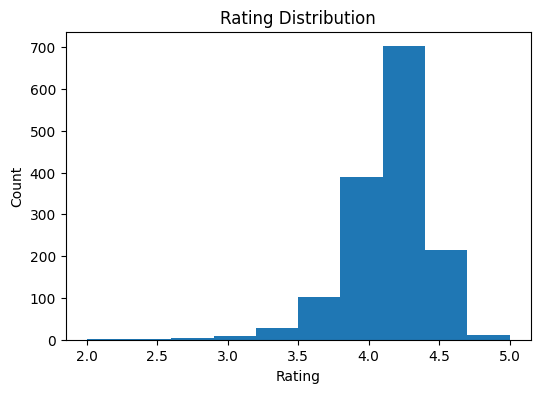

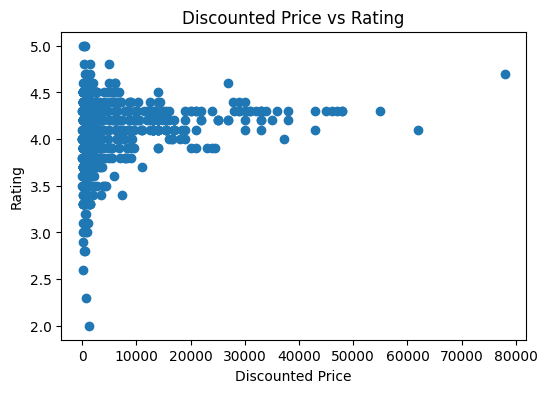

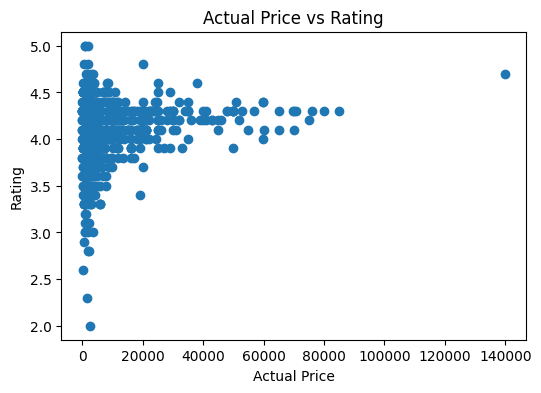

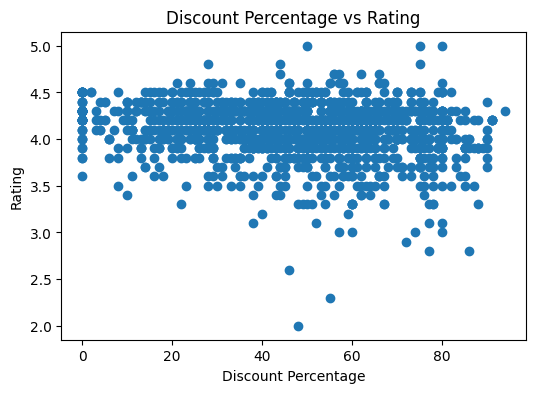

In [88]:

# --------------------------------------------
# Visualization
# --------------------------------------------

# 1. Rating Distribution
plt.figure(figsize=(6,4))
plt.hist(data['rating'], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# 2. Discounted Price vs Rating
plt.figure(figsize=(6,4))
plt.scatter(data['discounted_price'], data['rating'])
plt.title("Discounted Price vs Rating")
plt.xlabel("Discounted Price")
plt.ylabel("Rating")
plt.show()

# 3. Actual Price vs Rating
plt.figure(figsize=(6,4))
plt.scatter(data['actual_price'], data['rating'])
plt.title("Actual Price vs Rating")
plt.xlabel("Actual Price")
plt.ylabel("Rating")
plt.show()

# 4. Discount Percentage vs Rating
plt.figure(figsize=(6,4))
plt.scatter(data['discount_percentage'], data['rating'])
plt.title("Discount Percentage vs Rating")
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")
plt.show()

In [93]:
# --------------------------------------------
# Machine Learning Model
# --------------------------------------------

# Predicted Ratings
print("Predicted Ratings:")
print(y_pred)

# Actual Ratings
print("\nActual Ratings:")
print(y_test.values)

# Compare Actual vs Predicted
result = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

print("\nComparison:")
print(result.head(10))   # Display first 10 predictions

Predicted Ratings:
[4.14979316 4.05482765 4.0573517  4.07865827 4.05951515 4.14251927
 4.05482765 4.0629334  4.13598165 4.06597872 4.07770975 4.06281267
 4.15791087 4.16984798 4.12330049 4.04367907 4.10712026 4.06609745
 4.077834   4.10954345 4.13679236 4.10171386 4.05282059 4.07290685
 4.0122358  4.10592354 4.05381803 4.02261294 4.1668718  4.06237291
 4.06155665 4.06945894 4.077834   4.16749803 4.04591222 4.25811433
 4.16505448 4.03523922 4.16641052 4.14813825 4.19578202 4.04591222
 4.10099922 4.13675466 4.15404104 4.10526601 4.16262996 4.09232768
 4.05381803 4.00795261 4.2026742  4.10310964 4.16584303 4.09419349
 4.05429034 4.05787276 4.18183456 4.17511007 4.0444855  4.10115733
 4.10265572 4.07726227 4.04546216 4.14600462 4.16265501 4.06609745
 4.03852454 4.05482765 4.14915743 4.03447273 4.06492386 4.09202368
 4.12367239 4.01898029 4.15826871 4.08494801 3.99755011 4.03335505
 4.17423181 4.01618073 4.08726193 4.12335845 4.06612293 4.01841142
 4.02367687 4.14387076 4.06913355 4.0295405

In [94]:
# --------------------------------------------
# Evaluation
# --------------------------------------------

print("\nModel Evaluation")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))



Model Evaluation
MAE : 0.20773798779011216
MSE : 0.07483418976529273
R2 Score : 0.03559810778214567


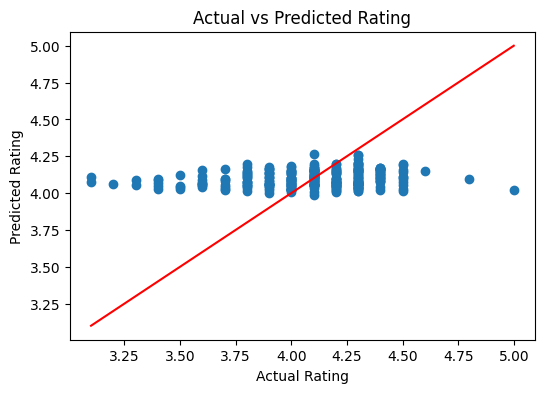

In [95]:
# --------------------------------------------
# Actual vs Predicted Graph
# --------------------------------------------

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Rating")
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red')
plt.show()


In [96]:
# --------------------------------------------
# Predict New Product Rating
# --------------------------------------------

sample = pd.DataFrame({
    'discounted_price':[500],
    'actual_price':[1000],
    'discount_percentage':[50]
})

prediction = model.predict(sample)

print("\nPredicted Rating:", prediction[0])


Predicted Rating: 4.080229017324284
